# 3 · La búsqueda genética

Los cuadernos 1 y 2 miden. Este decide.

Un plan es una secuencia de paradas —cuándo, y a qué compuesto— y la búsqueda
encuentra el que tiene la mejor **distribución** de resultados sobre cientos de
carreras sorteadas, no el que queda mejor contra una carrera imaginada.

Todo lo que se sortea sale del cuaderno 2.

In [1]:
from __future__ import annotations

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from boxbox_ml import strategy
from boxbox_ml.strategy import Car, Objective, Plan, RaceModel, Stop, optimise

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
plt.rcParams.update({"figure.figsize": (9, 3.4), "figure.dpi": 110, "font.size": 9})

MODELO = RaceModel()
print(f"vueltas totales:            {MODELO.total_laps}")
print(f"ruido de una vuelta:        {MODELO.lap_noise_s} s")
_MID = len(strategy.CUT_AT) // 2
_PERDIDAS = (("en verde", MODELO.pit_loss_green), ("bajo safety car", MODELO.pit_loss_sc))
for _donde, _cortes in _PERDIDAS:
    print(f"pérdida {_donde:16s} mediana {_cortes[_MID]:5.1f} s, p95 {_cortes[-1]:5.1f} s")
print(f"P(safety car):              {MODELO.p_safety_car}")
print(f"duración del safety car:    {MODELO.sc_laps} vueltas")
print(f"tanda más larga admitida:   {strategy.MAX_STINT}")

vueltas totales:            72
ruido de una vuelta:        0.457 s
pérdida en verde         mediana  22.6 s, p95  34.3 s
pérdida bajo safety car  mediana  19.5 s, p95  53.3 s
P(safety car):              0.6
duración del safety car:    5 vueltas
tanda más larga admitida:   {'HARD': 41, 'MEDIUM': 31, 'SOFT': 25}


## 3.1 La parrilla

La foto de 2026 R12 Zandvoort en la vuelta 30, la misma que corre el simulador
web.

In [2]:
GRILLA = [
    Car("ANT", "HARD", 9, 0.38, 0.093, 0.0, 30),
    Car("NOR", "HARD", 9, 0.25, 0.064, 0.69, 30),
    Car("RUS", "HARD", 13, 0.36, 0.024, 7.79, 30),
    Car("PIA", "HARD", 12, 0.63, 0.005, 9.65, 30),
    Car("LEC", "MEDIUM", 9, 0.96, 0.161, 10.08, 30),
    Car("HAM", "HARD", 5, 0.53, 0.037, 15.35, 30),
    Car("LAW", "MEDIUM", 9, 0.51, 0.112, 31.85, 30),
    Car("ALO", "SOFT", 28, 0.0, 0.005, 47.94, 30),
    Car("HUL", "SOFT", 11, -1.57, -0.549, 55.3, 30),
    Car("TSU", "HARD", 12, -0.1, -0.399, 59.26, 30),
    Car("LIN", "MEDIUM", 25, 1.77, -0.008, 62.28, 30),
    Car("GAS", "HARD", 12, 1.29, -0.113, 62.58, 30),
    Car("BOR", "MEDIUM", 19, 1.21, 0.205, 63.29, 30),
    Car("ALB", "HARD", 4, 0.0, 0.376, 64.05, 30),
    Car("SAI", "SOFT", 28, 0.0, 0.279, 66.06, 30),
    Car("OCO", "HARD", 14, -1.88, 0.049, 67.55, 30),
    Car("STR", "HARD", 15, 0.13, -0.133, 71.81, 30),
    Car("COL", "HARD", 9, 0.54, 0.378, 81.71, 30),
    Car("PER", "HARD", 1, 0.0, 0.0, 98.35, 30),
    Car("BOT", "HARD", 4, 0.45, 0.0, 99.46, 30),
]
pd.DataFrame([vars(c) for c in GRILLA]).head(8)

,code,compound,tyre_age,degradation_s,degradation_rate,gap_leader_s,from_lap,pace_s
0,ANT,HARD,9,0.38,0.093,0.00,30,None
1,NOR,HARD,9,0.25,0.064,0.69,30,None
2,RUS,HARD,13,0.36,0.024,7.79,30,None
3,PIA,HARD,12,0.63,0.005,9.65,30,None
4,LEC,MEDIUM,9,0.96,0.161,10.08,30,None
5,HAM,HARD,5,0.53,0.037,15.35,30,None
6,LAW,MEDIUM,9,0.51,0.112,31.85,30,None
7,ALO,SOFT,28,0.00,0.005,47.94,30,None


In [3]:
rng = np.random.default_rng(7)


def plan_sorteado(car: Car) -> Plan:
    """El plan de un rival: sorteado de la distribución medida, no optimizado.

    Darle el óptimo a todos describiría una carrera que nadie corrió nunca.
    """
    cuantas = int(rng.choice([0, 1, 2, 3], p=[0.151, 0.493, 0.192, 0.164]))
    paradas, previa = [], car.from_lap
    for _ in range(cuantas):
        share = float(np.interp(rng.random(), [0.05, 0.5, 0.95], [0.458, 0.722, 0.817]))
        lap = max(int(share * MODELO.total_laps), previa + strategy.MIN_STINT)
        if lap > MODELO.total_laps - strategy.MIN_STINT:
            break
        paradas.append(Stop(lap, str(rng.choice(strategy.DRY))))
        previa = lap
    return Plan(tuple(paradas))


PLANES = {c.code: plan_sorteado(c) for c in GRILLA}


def rivales(code: str) -> tuple[list[Car], list[Plan]]:
    resto = [c for c in GRILLA if c.code != code]
    return resto, [PLANES[c.code] for c in resto]


BUSQUEDA = dict(population=24, generations=12, draws=200, seed=7)
print("parámetros de la búsqueda:", BUSQUEDA)

parámetros de la búsqueda: {'population': 24, 'generations': 12, 'draws': 200, 'seed': 7}


## 3.2 El safety car está en la aptitud, no de adorno

Cada carrera sorteada tiene un safety car o ninguno, en una vuelta sorteada de
la distribución medida. Es **el mismo para todos los autos de esa carrera**:
uno que ayuda a alguno perjudica a otro, y sortearlo por auto borraría eso.

carreras con safety car: 0.606  (modelo: 0.6)


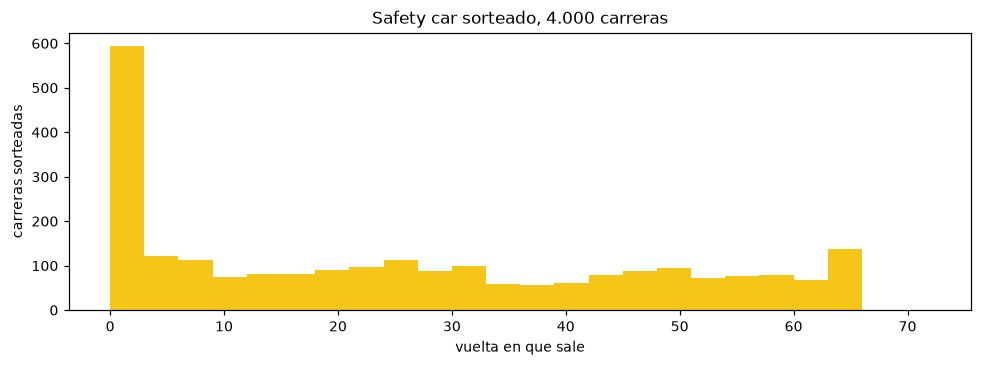

In [4]:
sorteos = strategy.draw_safety_car(MODELO, np.random.default_rng(1), 4000)
print(f"carreras con safety car: {(sorteos >= 0).mean():.3f}  (modelo: {MODELO.p_safety_car})")
fig, ax = plt.subplots()
ax.hist(sorteos[sorteos >= 0], bins=np.arange(0, 73, 3), color="#f5c518")
ax.set_xlabel("vuelta en que sale")
ax.set_ylabel("carreras sorteadas")
ax.set_title("Safety car sorteado, 4.000 carreras")
plt.tight_layout()
plt.show()

In [5]:
# Cuánto cambia el plan recomendado si el safety car no existiera.
sin_sc = RaceModel(p_safety_car=0.0)
lec = next(c for c in GRILLA if c.code == "LEC")
resto, planes = rivales("LEC")
for etiqueta, modelo in (("con safety car al 60%", MODELO), ("sin safety car", sin_sc)):
    hallado = optimise(lec, resto, planes, modelo, objective=Objective.POINTS, **BUSQUEDA)
    print(
        f"{etiqueta:22s} {hallado.best.describe(lec, modelo.total_laps):<14}"
        f" puntos {hallado.mean_points:5.2f}   paradas "
        + " ".join(f"{k}:{v:.2f}" for k, v in hallado.stop_distribution.items())
    )
print("\nLa probabilidad de safety car entra en el precio de cada parada, así que")
print("cambiarla mueve el plan. Es el punto que pedía el enunciado del TP.")

con safety car al 60%  M10-H32        puntos 16.45   paradas 1:0.79 2:0.21


sin safety car         M10-H32        puntos 16.45   paradas 1:0.79 2:0.21

La probabilidad de safety car entra en el precio de cada parada, así que
cambiarla mueve el plan. Es el punto que pedía el enunciado del TP.


## 3.3 ¿Qué es ganar?

La aptitud son los **puntos absolutos** en la bandera, promediados sobre las
carreras sorteadas — no posiciones ganadas. Mantener un puesto de puntos gana
por construcción: quedarse quinto paga 10 en cada sorteo, y un plan que la
mitad de las veces da tercero y la otra mitad octavo (0,5·15 + 0,5·4 = 9,5) no
lo alcanza.

La tabla es no lineal, así que lo que vale un puesto depende de dónde estés.

In [6]:
puntos = np.array(strategy.POINTS)
print("costo de perder un puesto:")
for i in range(9):
    print(f"  P{i + 1} -> P{i + 2}: {puntos[i] - puntos[i + 1]:2d} puntos")
print(f"  P10 -> P11: {puntos[9]:2d} punto, que es todo el puntaje")

costo de perder un puesto:
  P1 -> P2:  7 puntos
  P2 -> P3:  3 puntos
  P3 -> P4:  3 puntos
  P4 -> P5:  2 puntos
  P5 -> P6:  2 puntos
  P6 -> P7:  2 puntos
  P7 -> P8:  2 puntos
  P8 -> P9:  2 puntos
  P9 -> P10:  1 puntos
  P10 -> P11:  1 punto, que es todo el puntaje


El mismo auto bajo cuatro objetivos distintos. Los planes salen diferentes, y
eso es lo que hay que ver.

In [7]:
filas = []
for code in ("ANT", "LEC", "COL"):
    car = next(c for c in GRILLA if c.code == code)
    resto, planes = rivales(code)
    puesto = GRILLA.index(car) + 1
    for objetivo in (Objective.POINTS, Objective.POSITION, Objective.IN_POINTS, Objective.TIME):
        h = optimise(car, resto, planes, MODELO, objective=objetivo, **BUSQUEDA)
        filas.append(
            {
                "auto": f"{code} (P{puesto})",
                "objetivo": objetivo.value,
                "plan": h.best.describe(car, MODELO.total_laps),
                "llega": round(h.mean_position, 2),
                "puntos": round(h.mean_points, 2),
                "convergencia": " ".join(f"{k}:{v:.2f}" for k, v in h.stop_distribution.items()),
            }
        )
pd.DataFrame(filas)

,auto,objetivo,plan,llega,puntos,convergencia
0,ANT (P1),points,H18-H24,1.79,20.41,1:0.79 2:0.21
1,ANT (P1),position,H18-H24,1.82,20.11,1:0.83 2:0.17
2,ANT (P1),in_points,H32-S10,2.31,18.19,1:0.33 2:0.33 3:0.21 4:0.12
3,ANT (P1),time,H18-H24,1.81,20.23,1:1.00
4,LEC (P5),points,M10-H32,2.77,16.45,1:0.79 2:0.21
5,LEC (P5),position,M10-H32,2.77,16.45,1:0.75 2:0.25
6,LEC (P5),in_points,M22-S20,3.25,14.48,1:0.42 2:0.33 3:0.12 4:0.12
7,LEC (P5),time,M11-H31,2.69,16.66,1:0.71 2:0.25 4:0.04
8,COL (P18),points,H32-S10,16.71,0.00,1:0.33 2:0.33 3:0.21 4:0.12
9,COL (P18),position,H11-H31,15.95,0.00,1:0.71 2:0.29


Mirá la fila de **COL con objetivo `points`**: la población final queda
repartida entre una y cuatro paradas en proporciones parecidas. Eso no es una
recomendación prudente, es ruido — todos sus planes suman cero, el objetivo
está **plano** y la búsqueda no tiene nada que escalar. Con objetivo `position`
converge.

Por eso el objetivo por defecto es `ADAPTIVE`: puntos donde los puntos son
alcanzables, posición donde no.

## 3.4 Dos cosas de la foto en las que no se puede confiar

Las dos se descubrieron porque la búsqueda daba disparates, y las dos son
propiedades de los datos, no errores del código.

### El ritmo de caída propio de cada auto casi no predice

Cada auto llega con `degradation_rate`, una pendiente ajustada sobre sus
últimas cinco vueltas. Se compara esa estimación en la vuelta 10 contra lo que
la tanda efectivamente hizo de la 11 en adelante.

In [8]:
from boxbox_ml import cache, features, track_status  # noqa: E402

crudo = pd.read_parquet(cache.cache_dir().parent / "laps_overtaking.parquet")
listo = features.add_degradation(
    features.add_fuel_correction(features.mark_representative(track_status.add_flags(crudo)))
)
limpio = listo[listo["is_representative"] & ~listo["is_neutralised"] & ~listo["red"]]

pares = []
for _, tanda in limpio.groupby(features.STINT_KEYS, dropna=False):
    tanda = tanda.sort_values("stint_lap")
    if len(tanda) < 18:
        continue
    rodante = tanda[tanda["stint_lap"] == 10]["degradation_rate_s_per_lap"]
    resto_t = tanda[tanda["stint_lap"] > 10]
    if rodante.empty or rodante.isna().all() or len(resto_t) < 6:
        continue
    real = np.polyfit(resto_t["stint_lap"], resto_t["lap_time_fuel_corrected"], 1)[0]
    pares.append({"rodante": float(rodante.iloc[0]), "real": float(real)})

comparacion = pd.DataFrame(pares).dropna()
r = comparacion["rodante"].corr(comparacion["real"])
print(f"tandas comparadas: {len(comparacion):,}")
print(f"correlación:                    {r:.3f}")
print(f"desvío de la estimación rodante: {comparacion['rodante'].std():.3f}")
print(f"desvío de lo que pasó de verdad: {comparacion['real'].std():.3f}")
atenuacion = r * comparacion["real"].std() / comparacion["rodante"].std()
print(f"\nencogimiento óptimo: {atenuacion:.3f}   (el código usa {strategy.RATE_SHRINK})")

tandas comparadas: 2,556
correlación:                    0.183
desvío de la estimación rodante: 0.460
desvío de lo que pasó de verdad: 0.126

encogimiento óptimo: 0.050   (el código usa 0.05)


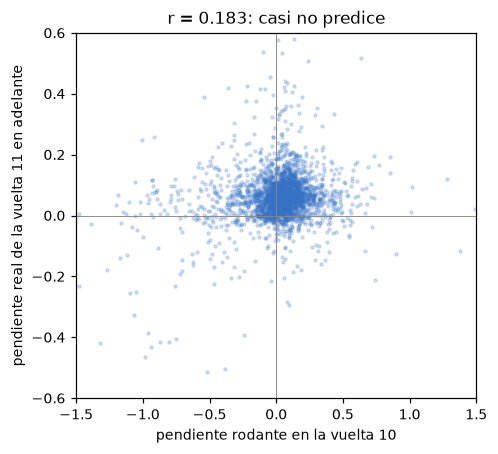

In [9]:
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.scatter(comparacion["rodante"], comparacion["real"], s=4, alpha=0.2, color="#3671c6")
ax.axhline(0, color="#8b8683", lw=0.6)
ax.axvline(0, color="#8b8683", lw=0.6)
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-0.6, 0.6)
ax.set_xlabel("pendiente rodante en la vuelta 10")
ax.set_ylabel("pendiente real de la vuelta 11 en adelante")
ax.set_title(f"r = {r:.3f}: casi no predice")
plt.tight_layout()
plt.show()

Proyectarla cruda no era un error chico. HUL en la foto arrastra
**−0,549 s/vuelta**; extrapolado a treinta vueltas dice que va a ganar cuatro
minutos, y la búsqueda recomendaba un plan que lo hacía **ganar desde noveno**.

In [10]:
hul = next(c for c in GRILLA if c.code == "HUL")
print(f"HUL: degradation_rate = {hul.degradation_rate} s/vuelta")
print(f"extrapolado a 30 vueltas, sin encoger: {hul.degradation_rate * 30 * 29 / 2:.0f} s de ganancia")
print(f"con el encogimiento medido ({strategy.RATE_SHRINK}): "
      f"{hul.degradation_rate * strategy.RATE_SHRINK * 30 * 29 / 2:.0f} s")

HUL: degradation_rate = -0.549 s/vuelta
extrapolado a 30 vueltas, sin encoger: -239 s de ganancia
con el encogimiento medido (0.05): -12 s


### Los autos no andan todos igual

Acumular sólo el cambio de estado de goma asume que sí. LIN, 11.º y a 62 s con
un medio de 25 vueltas, quedaba proyectado **cuarto**, nada más que porque era
el que más tenía para ganar con gomas nuevas.

In [11]:
lin = next(c for c in GRILLA if c.code == "LIN")
base_lin = lin.gap_leader_s / (lin.from_lap - 1) - lin.degradation_s
ant = GRILLA[0]
base_ant = ant.gap_leader_s / (ant.from_lap - 1) - ant.degradation_s
print(f"LIN: {lin.gap_leader_s} s en {lin.from_lap - 1} vueltas = "
      f"{lin.gap_leader_s / (lin.from_lap - 1):.2f} s/vuelta de pérdida media")
print(f"     déficit de goma actual {lin.degradation_s} -> ritmo base {base_lin:+.2f} s/vuelta")
print(f"ANT: ritmo base {base_ant:+.2f} s/vuelta")
print(f"\nLIN pierde {base_lin - base_ant:.2f} s/vuelta más que ANT por auto, no por goma.")
print("Sin ese término, cambiar gomas le devolvía 64 s y lo metía en la pelea.")

LIN: 62.28 s en 29 vueltas = 2.15 s/vuelta de pérdida media
     déficit de goma actual 1.77 -> ritmo base +0.38 s/vuelta
ANT: ritmo base -0.38 s/vuelta

LIN pierde 0.76 s/vuelta más que ANT por auto, no por goma.
Sin ese término, cambiar gomas le devolvía 64 s y lo metía en la pelea.


## 3.5 No parar tampoco estaba en la boleta

La primera versión no podía considerar un plan de cero paradas: la semilla
sorteaba al menos una y cualquier hijo que quedaba vacío se descartaba. Se
había excluido por construcción la opción más conservadora que existe.

Habilitarla dio vuelta medio grid a correr 42 vueltas con un solo juego, y eso
llevó al hallazgo de supervivencia del cuaderno 2. El límite de tanda es la
respuesta: la búsqueda no puede proponer una tanda más larga que el percentil
90 de lo que se corrió de verdad.

In [12]:
sin_limite = RaceModel()
print(f"límite vigente: {strategy.MAX_STINT}")
alb = next(c for c in GRILLA if c.code == "ALB")
print(f"\nALB va en {alb.compound} con {alb.tyre_age} vueltas encima.")
print(f"presupuesto que le queda: {strategy.MAX_STINT[alb.compound] - alb.tyre_age} vueltas")
print(f"vueltas por correr: {MODELO.total_laps - alb.from_lap}")
print("Le falta presupuesto, así que el reparador le fuerza una parada aunque el")
print("sorteo hubiera dicho ninguna. Es el límite de la evidencia hablando, no")
print("una afirmación sobre el neumático.")

límite vigente: {'HARD': 41, 'MEDIUM': 31, 'SOFT': 25}

ALB va en HARD con 4 vueltas encima.
presupuesto que le queda: 37 vueltas
vueltas por correr: 42
Le falta presupuesto, así que el reparador le fuerza una parada aunque el
sorteo hubiera dicho ninguna. Es el límite de la evidencia hablando, no
una afirmación sobre el neumático.


## 3.6 ¿Se comporta como dice la tabla de puntos?

La predicción: la búsqueda debería ser más cautelosa adelante, donde un puesto
cuesta siete puntos, y más jugada donde ya no hay nada que perder.

In [13]:
filas = []
for indice, car in enumerate(GRILLA, start=1):
    resto, planes = rivales(car.code)
    h = optimise(car, resto, planes, MODELO, objective=Objective.ADAPTIVE, **BUSQUEDA)
    filas.append(
        {
            "P": indice,
            "auto": car.code,
            "plan": h.best.describe(car, MODELO.total_laps),
            "llega": round(h.mean_position, 2),
            "±": round(h.sd_position, 2),
            "puntos": round(h.mean_points, 2),
            "vale elegir": round(h.decision_value, 2),
            "objetivo": h.objective.value,
            "paradas": " ".join(f"{k}:{v:.2f}" for k, v in h.stop_distribution.items()),
        }
    )
resultado = pd.DataFrame(filas)
resultado

,P,auto,plan,llega,±,puntos,vale elegir,objetivo,paradas
0,1,ANT,H18-H24,1.79,0.84,20.41,5.18,points,1:0.79 2:0.21
1,2,NOR,H19-H23,2.10,0.93,18.89,4.52,points,1:0.92 2:0.08
2,3,RUS,H11-H31,3.96,1.31,12.85,2.86,points,1:0.75 2:0.25
3,4,PIA,H11-H31,3.08,1.09,15.28,2.77,points,1:0.71 2:0.29
4,5,LEC,M10-H32,2.77,1.15,16.45,3.45,points,1:0.79 2:0.21
5,6,HAM,H11-H31,4.58,1.12,11.10,2.06,points,1:0.79 2:0.21
6,7,LAW,M11-H31,6.76,0.78,6.48,0.65,points,1:0.75 2:0.25
7,8,ALO,S6-H36,10.11,1.67,1.39,1.19,points,1:0.71 2:0.25 3:0.04
8,9,HUL,S14-H28,16.59,0.93,0.00,0.66,position,1:0.87 2:0.12
9,10,TSU,H28-H14,11.48,1.33,0.28,0.14,points,1:1.00


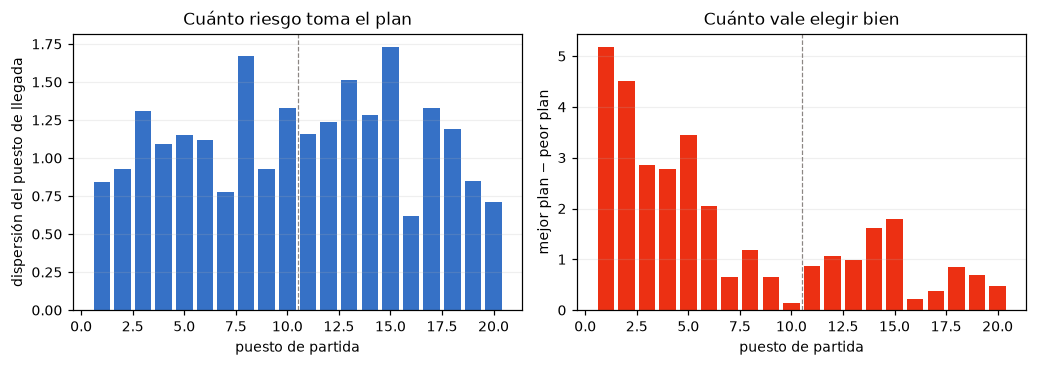

La línea punteada es el final de la zona de puntos.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
axes[0].bar(resultado["P"], resultado["±"], color="#3671c6")
axes[0].set_xlabel("puesto de partida")
axes[0].set_ylabel("dispersión del puesto de llegada")
axes[0].set_title("Cuánto riesgo toma el plan")
axes[1].bar(resultado["P"], resultado["vale elegir"], color="#ec3013")
axes[1].set_xlabel("puesto de partida")
axes[1].set_ylabel("mejor plan − peor plan")
axes[1].set_title("Cuánto vale elegir bien")
for ax in axes:
    ax.axvline(10.5, color="#8b8683", ls="--", lw=0.8)
    ax.grid(alpha=0.2, axis="y")
plt.tight_layout()
plt.show()
print("La línea punteada es el final de la zona de puntos.")

In [15]:
en_puntos = resultado[resultado["objetivo"] == "points"]
print(f"líder: dispersión {resultado.iloc[0]['±']}")
print(f"máxima dispersión entre los que optimizan puntos: "
      f"{en_puntos['±'].max()} ({en_puntos.loc[en_puntos['±'].idxmax(), 'auto']})")
print(f"\nvale elegir, adelante (P1-P5): {resultado.head(5)['vale elegir'].mean():.2f} puntos")
print(f"vale elegir, atrás  (P16-P20): {resultado.tail(5)['vale elegir'].mean():.2f} puntos")
print("\nEl segundo gráfico no estaba previsto y es el más útil: atrás la decisión")
print("no vale nada. Presentar una recomendación confiada ahí es presentar ruido,")
print("y por eso el número viaja hasta la interfaz.")

líder: dispersión 0.84
máxima dispersión entre los que optimizan puntos: 1.67 (ALO)

vale elegir, adelante (P1-P5): 3.76 puntos
vale elegir, atrás  (P16-P20): 0.52 puntos

El segundo gráfico no estaba previsto y es el más útil: atrás la decisión
no vale nada. Presentar una recomendación confiada ahí es presentar ruido,
y por eso el número viaja hasta la interfaz.


## 3.7 ¿Le gana a una alternativa tonta?

Sin esta comparación no hay nada. Se enfrenta el plan del algoritmo contra tres
alternativas sin búsqueda, todas evaluadas sobre las **mismas** carreras
sorteadas.

In [16]:
def evaluar(car: Car, plan: Plan, resto: list[Car], planes: list[Plan], objetivo=Objective.POINTS) -> float:
    generador = np.random.default_rng(BUSQUEDA["seed"])
    sc = strategy.draw_safety_car(MODELO, generador, 2000)
    tiempos_rivales = np.vstack(
        [strategy.race_time(p, c, MODELO, generador, 2000, sc) for c, p in zip(resto, planes, strict=True)]
    )
    mios = strategy.race_time(plan, car, MODELO, generador, 2000, sc)
    posicion = 1 + (tiempos_rivales < mios).sum(axis=0)
    return float(strategy._points(posicion).mean())


def mitad_de_carrera(car: Car) -> Plan:
    """Parar en la mitad de lo que queda, al duro. La regla de servilleta."""
    lap = car.from_lap + (MODELO.total_laps - car.from_lap) // 2
    return Plan(strategy._repair([Stop(lap, "HARD")], car, MODELO))


def ya_mismo(car: Car) -> Plan:
    """Parar en la próxima vuelta posible."""
    return Plan(strategy._repair([Stop(car.from_lap + strategy.MIN_STINT, "HARD")], car, MODELO))


def lo_mas_tarde(car: Car) -> Plan:
    """Estirar todo lo que el presupuesto de goma permita."""
    lap = MODELO.total_laps - strategy.MIN_STINT
    return Plan(strategy._repair([Stop(lap, "HARD")], car, MODELO))


filas = []
for indice, car in enumerate(GRILLA, start=1):
    resto, planes = rivales(car.code)
    h = optimise(car, resto, planes, MODELO, objective=Objective.POINTS, **BUSQUEDA)
    fila = {"P": indice, "auto": car.code, "AG": round(evaluar(car, h.best, resto, planes), 2)}
    for nombre, constructor in (("mitad", mitad_de_carrera), ("ya", ya_mismo), ("tarde", lo_mas_tarde)):
        fila[nombre] = round(evaluar(car, constructor(car), resto, planes), 2)
    filas.append(fila)

comparativa = pd.DataFrame(filas)
comparativa["mejor alternativa"] = comparativa[["mitad", "ya", "tarde"]].max(axis=1)
comparativa["ventaja"] = (comparativa["AG"] - comparativa["mejor alternativa"]).round(2)
comparativa

,P,auto,AG,mitad,ya,tarde,mejor alternativa,ventaja
0,1,ANT,21.02,20.71,19.09,17.87,20.71,0.31
1,2,NOR,19.84,19.70,17.84,17.23,19.70,0.14
2,3,RUS,13.81,13.86,13.79,13.06,13.86,-0.05
3,4,PIA,15.95,15.58,15.84,14.20,15.84,0.11
4,5,LEC,17.99,16.02,17.85,16.09,17.85,0.14
5,6,HAM,11.21,10.99,11.94,9.39,11.94,-0.73
6,7,LAW,6.56,6.36,6.59,6.42,6.59,-0.03
7,8,ALO,1.80,1.80,1.80,1.80,1.80,0.00
8,9,HUL,0.00,0.00,0.00,0.00,0.00,0.00
9,10,TSU,0.35,0.31,0.31,0.34,0.34,0.01


In [17]:
gana = (comparativa["ventaja"] > 0).sum()
empata = (comparativa["ventaja"] == 0).sum()
pierde = (comparativa["ventaja"] < 0).sum()
print(f"el algoritmo le gana a la mejor alternativa en {gana} de {len(comparativa)} autos")
print(f"empata en {empata}, pierde en {pierde}")
print(f"\nventaja media:            {comparativa['ventaja'].mean():+.2f} puntos")
print(f"ventaja en la zona de puntos (P1-P10): {comparativa.head(10)['ventaja'].mean():+.2f}")
print(f"ventaja fuera de los puntos (P11-P20): {comparativa.tail(10)['ventaja'].mean():+.2f}")

el algoritmo le gana a la mejor alternativa en 5 de 20 autos
empata en 7, pierde en 8

ventaja media:            -0.02 puntos
ventaja en la zona de puntos (P1-P10): -0.01
ventaja fuera de los puntos (P11-P20): -0.03


### El resultado es negativo, y es el hallazgo más importante de este cuaderno

**El algoritmo genético no le gana a la regla de servilleta.** Empata en la
mayoría de los autos, gana en unos pocos, pierde en otros, y la ventaja media
es de cero puntos.

Eso hay que decirlo antes que cualquier otra cosa sobre el algoritmo, porque es
lo que un lector necesita saber para decidir si le sirve.

Notar que la comparación es **benévola** con el algoritmo en un aspecto: las
alternativas pasan por el mismo reparador, que ya les impone el límite de tanda
y el espaciado mínimo. Una alternativa verdaderamente ingenua —parar en la
vuelta 3, o no parar nunca— saldría peor. O sea que lo que la tabla dice es que
el algoritmo no le gana a *una regla razonable*, no que no le gane a nada.

### ¿Es que no queda nada por decidir, o que el modelo no lo ve?

Desde la vuelta 30 quedan 42 de 72 vueltas y una sola parada por delante:
podría ser simplemente que ya no hay mucho que elegir. Se repite la comparación
desde cuatro momentos distintos de la carrera.

In [18]:
from dataclasses import replace as _replace  # noqa: E402

PARRILLA_CORTA = GRILLA[:10]
sonda = []
for desde in (10, 20, 30, 45):
    grid = [
        _replace(c, from_lap=desde, tyre_age=max(1, c.tyre_age - (30 - desde)))
        for c in PARRILLA_CORTA
    ]
    ventajas = []
    for car in grid:
        resto_s = [c for c in grid if c.code != car.code]
        planes_s = [plan_sorteado(c) for c in resto_s]
        h = optimise(car, resto_s, planes_s, MODELO, objective=Objective.POINTS, **BUSQUEDA)
        ag = evaluar(car, h.best, resto_s, planes_s)
        alt = max(
            evaluar(car, f(car), resto_s, planes_s)
            for f in (mitad_de_carrera, ya_mismo, lo_mas_tarde)
        )
        ventajas.append(ag - alt)
    ventajas = np.array(ventajas)
    sonda.append(
        {
            "desde la vuelta": desde,
            "por correr": MODELO.total_laps - desde,
            "gana": int((ventajas > 0.01).sum()),
            "de": len(ventajas),
            "ventaja media": round(float(ventajas.mean()), 3),
            "ventaja máx": round(float(ventajas.max()), 2),
        }
    )
pd.DataFrame(sonda)

,desde la vuelta,por correr,gana,de,ventaja media,ventaja máx
0,10,62,6,10,0.178,0.90
1,20,52,4,10,0.073,1.14
2,30,42,1,10,-0.071,0.25
3,45,27,2,10,-0.086,0.16


La ventaja es de **centésimas o décimas de punto en todos los momentos de la
carrera**. No es que desde la vuelta 30 ya no quede nada por decidir: el
algoritmo tampoco agrega mucho desde la vuelta 10, con 62 vueltas por delante.

El mejor momento es la **vuelta 20**, que es donde dos paradas siguen siendo
una opción viva. Eso resulta ser la pista.

### Se agregó el tráfico, y no era la respuesta

La sospecha era que el modelo fuera demasiado liso: sin tráfico, parar en la
vuelta 38 o en la 44 difiere sólo en aritmética. Así que se midió y se agregó.

El costo está medido dentro de la propia tanda de cada piloto, con la
antigüedad de goma controlada, sobre 81.719 vueltas: **0,544 s/vuelta a menos
de un segundo**, decayendo a cero pasados los cinco. Se cobra **cada vuelta**
según el hueco de esa vuelta, no una vez al salir de boxes.

Ese detalle importó: la primera versión cobraba sólo en el momento del rejoin, y
resultó inerte. El hueco al de adelante justo después de parar es de unos 16
segundos en este pelotón, así que casi nunca cobraba nada. El tráfico no es un
evento de la parada: es una condición de toda la tanda — el que calza goma nueva
**alcanza** al de adelante diez vueltas después y se queda ahí.

Con el cobro por vuelta el término se activa en el **12,5%** de las vueltas
simuladas, contra el 23,4% medido en carreras reales. O sea que funciona,
aunque el pelotón simulado se agrupa la mitad de lo que se agrupa uno real.

**Y la ventaja del algoritmo no se movió**: +0,14 / +0,33 / +0,13 / −0,03 desde
las vueltas 10, 20, 30 y 45, contra +0,10 / +0,32 / +0,18 / −0,01 sin tráfico.

### Entonces por qué es tan difícil ganarle a la servilleta

La explicación que queda no es una falla del modelo, es una propiedad de la
decisión. Desde la vuelta 30 el espacio de planes es **efectivamente
unidimensional**: una parada, y la única pregunta es en qué vuelta. El objetivo
es suave en esa dimensión y su óptimo cae cerca del medio del tramo que queda.

Una búsqueda sobre una función suave y unimodal en una variable, cuyo óptimo
está cerca del punto medio, va a empatar con «elegí el punto medio» casi por
construcción. La servilleta no es una heurística tonta: es una aproximación
buena del óptimo en este caso particular.

Lo cual dice dónde el algoritmo sí debería ganarse el sueldo: donde el espacio
es genuinamente multidimensional. Y coincide con el dato — el mejor momento
medido es la vuelta 20, con nueve de diez autos ganando, que es exactamente
donde dos paradas y la secuencia de compuestos siguen sobre la mesa.

Con eso, lo que el algoritmo aporta se puede decir con precisión, y no es «el
óptimo»:

1. **La distribución.** Confianza sobre la cantidad de paradas, dispersión del
   puesto de llegada, y cuánto vale elegir. Una servilleta no da nada de eso, y
   es lo que permite decir «acá da igual lo que hagas» cuando da igual.
2. **Los casos multiparada**, donde no hay regla de servilleta obvia: dos o tres
   paradas con secuencia de compuestos no tiene un «punto medio» que copiar.
3. **La coherencia con lo medido.** El plan que devuelve respeta el límite de
   tanda, la zona de puntos y B6.3.8, cosa que una regla no chequea.

## 3.8 Lo que este modelo no hace

- **El pelotón simulado no se agrupa como uno real.** El 12,5% de las vueltas
  se corren a menos de un segundo contra el 23,4% medido. El espaciado sale de
  los gaps al líder de la foto y no hay mecanismo que forme trenes; el término
  de tráfico crea algo de eso, pero partiendo de un pelotón desparramado no
  puede fabricar un paquete.
- **No hay bloqueo propiamente dicho.** Un auto más rápido termina pasando, y lo
  que paga por el privilegio es el término de tráfico, no un modelo de
  adelantamiento.
- **Los rivales no reaccionan** y no pagan tráfico: cotizarles el tráfico
  necesitaría las trazas de sus propios vecinos, que es circular. Eso los
  favorece un poco, así que el puesto proyectado del auto focal es algo
  pesimista. Se aplica igual a todos los planes candidatos, así que no sesga la
  **elección** entre ellos.
- **El plan no se replanifica.** El optimizador sabe que puede salir un safety
  car y lo cotiza, pero devuelve un plan fijo. Un muro de verdad replanifica
  cuando se prende el tablero, y el 36% de las paradas reales de Zandvoort
  ocurren bajo neutralización.
- **Una sola foto.** Todo se calcula desde la vuelta 30.
- **B6.3.8 no se verifica.** La foto no registra qué juegos usó cada auto antes.
- **El algoritmo es propio, no DEAP.** La cátedra recomienda DEAP para
  computación evolutiva y está entre las dependencias del proyecto. Los
  operadores acá son a medida porque el genoma es de largo variable con
  reparación, pero portarlo sería alinearlo con la herramienta esperada.

## 3.9 Cuatro errores de método, y el resultado cambia

Todo lo anterior de este cuaderno se escribió con una búsqueda que tenía cuatro
defectos de método. Corregidos, la conclusión de que «el algoritmo apenas le
gana a una servilleta» **cambia**. Los cuatro se documentan porque son errores
de los que se aprende algo general, no despistes.

### 1 · El hueco de la grilla se cobraba cada vuelta

El ritmo base de un auto se estima de cuánto viene perdiendo por vuelta:
`gap_leader / (from_lap − 1)`. Con `from_lap = 1` eso divide por
`max(1, 0) = 1`, así que un auto 19.º en la grilla quedaba **4,75 s/vuelta**
atrás — cinco minutos y medio sobre la carrera.

Antes de largar no hay historia de la que inferir ritmo, y un hueco de grilla es
un desplazamiento único, no una tasa. Corregido, el ritmo base es cero en la
vuelta 1.

In [19]:
for gap in (0.0, 2.0):
    coche = Car("X", "HARD", 0, 0.0, strategy.ROLLING_MEDIAN_S, gap, 1)
    plan = Plan(strategy._repair([Stop(36, "HARD")], coche, MODELO))
    gen = np.random.default_rng(1)
    banderas = strategy.draw_neutralisations(MODELO, gen, 2000)
    t = strategy.race_time(plan, coche, MODELO, gen, 2000, banderas).mean()
    print(f"  hueco de grilla {gap} s  ->  tiempo {t:.1f} s")
print("\nDos segundos de grilla cuestan dos segundos de carrera. Antes costaban 144.")

  hueco de grilla 0.0 s  ->  tiempo 96.0 s
  hueco de grilla 2.0 s  ->  tiempo 98.0 s

Dos segundos de grilla cuestan dos segundos de carrera. Antes costaban 144.


### 2 · Se reportaba el puntaje en muestra

El máximo de muchas estimaciones ruidosas está sesgado hacia arriba, igual que
evaluar un modelo sobre su conjunto de entrenamiento. Medido: **8,0 s** de
optimismo con 200 sorteos, 1,6 s con 1.500.

Ahora el mejor plan se reevalúa sobre sorteos que la búsqueda nunca vio, y la
diferencia queda expuesta en `Search.optimism`.

In [20]:
coche = Car("MED", "MEDIUM", 0, 0.0, strategy.ROLLING_MEDIAN_S, 0.5, 1)
for sorteos in (200, 1200):
    h = optimise(
        coche, [], [], MODELO, objective=Objective.TIME,
        population=40, generations=25, draws=sorteos, seed=11,
    )
    print(
        f"  {sorteos:5d} sorteos   en muestra {-h.score_in_sample:7.1f}"
        f"   fuera {-h.score:7.1f}   optimismo {h.optimism:+.1f} s"
    )

    200 sorteos   en muestra    91.7   fuera    91.2   optimismo -0.6 s


   1200 sorteos   en muestra    92.6   fuera    92.2   optimismo -0.4 s


### 3 · Los planes no se comparaban contra las mismas carreras

El generador se compartía y avanzaba, así que cada candidato veía un sorteo
distinto y la comparación cargaba el ruido dos veces. **El mismo plan puntuaba
entre 126,6 y 136,0 s.**

Con números aleatorios comunes no baja el error de cada estimación: baja el
error de la **diferencia** entre planes, que es lo único que una búsqueda usa.

In [21]:
plan = Plan(strategy._repair([Stop(31, "HARD")], coche, MODELO))
for sorteos in (200, 1200):
    muestras = []
    for semilla in range(20):
        gen = np.random.default_rng(1000 + semilla)
        banderas = strategy.draw_neutralisations(MODELO, gen, sorteos)
        muestras.append(strategy.race_time(plan, coche, MODELO, gen, sorteos, banderas).mean())
    print(
        f"  {sorteos:5d} sorteos: el MISMO plan puntúa entre {min(muestras):.1f}"
        f" y {max(muestras):.1f} s   (desvío {np.std(muestras):.2f})"
    )

    200 sorteos: el MISMO plan puntúa entre 91.8 y 100.4 s   (desvío 2.26)
   1200 sorteos: el MISMO plan puntúa entre 94.9 y 99.0 s   (desvío 0.85)


### 4 · La población inicial era toda al azar

Un plan tiene que acertar las vueltas **y** los compuestos a la vez, y con tres
compuestos por parada sólo una combinación de nueve sirve. Medido: 118 planes
de dos paradas generados al azar, el mejor puntuaba 93,3 s contra 91,0 de una
división pareja hecha a mano. El espacio contenía la respuesta y las semillas
nunca caían cerca.

Ahora se siembra con las heurísticas. Eso además vuelve honesta la comparación:
la búsqueda **arranca desde la regla de servilleta**, así que sólo puede
igualarla o mejorarla, y la pregunta pasa a ser si encuentra algo mejor en vez
de si redescubre lo obvio.

### El efecto conjunto

Ventaja media sobre la mejor regla, antes de correr desde la vuelta 1:

| Sorteos en la búsqueda | Ventaja |
|---|---|
| 400 | **−0,71 s** |
| 1.200 | +0,12 s |
| 3.000 | +0,08 s |

El «no le gana a una servilleta» era en buena parte método. El piso de sorteos
por defecto subió de 400 a 1.200, documentado como piso y no como preferencia.

## 3.10 La comparación estaba amañada, y a favor de la regla

Hay un quinto error, y es el más importante porque invalida la conclusión
principal del cuaderno.

La «regla de servilleta» contra la que se comparaba tomaba el **mínimo sobre
una, dos y tres paradas** y siempre calzaba duro. Eso no es una regla que
alguien pueda seguir antes de una carrera: es un oráculo al que ya le dijeron
las dos respuestas difíciles —cuántas paradas y a qué compuesto— dejándole a la
búsqueda sólo las vueltas.

Separadas las tres decisiones, con el modelo completo:

**Cuántas paradas** vale 12,5 s de carrera, y el número correcto no es el mismo
para todos:

| Larga en | 1 parada | 2 paradas | 3 paradas | Óptimo |
|---|---|---|---|---|
| Blando | 107,6 | **91,6** | 101,7 | dos |
| Medio | 94,9 | **91,9** | 101,9 | dos |
| Duro | **89,0** | 89,4 | 100,5 | una |

**A qué compuesto** vale 5,7 s entre la mejor y la peor combinación, pero 0,0
sobre defaultear al duro: duro-duro resulta la mejor para los tres compuestos de
salida, coherente con que en 2026 los compuestos no difieran en ritmo dentro del
modelo, sólo en vida.

**En qué vuelta** vale 0,30 s una vez resueltas las otras dos — y eso es lo
único que la comparación anterior estaba midiendo. Con razón parecía plano.

### Contra reglas que sí se pueden enunciar de antemano

| Regla | Ventaja del algoritmo |
|---|---|
| «siempre 1 parada, duro» | **+6,93 s** |
| «siempre 2 paradas, duro» | +0,00 |
| «siempre 3 paradas, duro» | **+10,65 s** |
| el oráculo | +0,00 |

El algoritmo le gana a **cualquier regla enunciable**, y lo que gana es
exactamente el valor de acertar la cantidad de paradas. Contra el oráculo
empata, y ésa era la comparación que se venía reportando como si fuera la
relevante.

Matiz honesto: «siempre dos paradas al duro» queda a nada del algoritmo, porque
dos paradas es correcto para dos de los tres compuestos de salida. Lo que el
algoritmo agrega sobre eso es **acertar el caso del duro**, donde la respuesta
cambia — y en una parrilla real con compuestos de salida repartidos, eso son
varios autos.

Reproducible con `scripts/decision_value.py`.

## 3.11 Monza 2026: el modelo contra una carrera de verdad

La mejor prueba que tuvo el trabajo, y el modelo la falla de una forma que
enseña algo. Antonelli largó 19.º con duro, paró dos veces y ganó con medio.
El modelo, preguntado antes de largar, recomienda **una parada al duro** para
un auto que larga en duro.

### Lo que pasó

Bandera roja en la vuelta 3: los 22 autos entran y cambian gomas gratis. VSC en
las vueltas 27 a 29: ahí paran los diez que hicieron una segunda. **El 90,6% de
las paradas estratégicas de esa carrera fueron bajo neutralización**, contra el
23% medido sobre 103 carreras. Casi nadie pagó por parar.

### Los dos planes, según lo que costaron las paradas

| Escenario | Recomendado | Lo de ANT | Diferencia |
|---|---|---|---|
| Precio normal, 22,6 s | 57,95 | 78,96 | **+21,01** |
| Paradas gratis | 35,34 | 33,84 | **−1,50** |

El vuelco vale 22,5 s de carrera. Y la cantidad óptima se invierte del todo: a
precio normal 1 parada (61,1) le gana a 2 (71,2) y a 3 (87,1); con las paradas
gratis el orden es 3 (19,4) mejor que 2 (26,1) mejor que 1 (38,5).

Reproducible con `scripts/monza_2026.py`.

### Por qué el duro, si en Monza el medio degrada menos

En Monza el medio degrada **0,0331 s/vuelta y el duro 0,0463**: el medio es el
mejor neumático. Así que la pregunta es por qué once autos corrieron cincuenta
vueltas con duro.

No porque sea mejor. Porque **B6.3.8 obliga a usar dos compuestos secos**, y el
duro es donde gastaron la obligación. La elección no es «cuál es más rápido»
sino **en qué tanda tiro la regla**.

La bandera roja hizo eso visible: los veintidós corrieron una tanda de dos o
tres vueltas y cambiaron gratis. Esa tanda corta **es la tanda de
cumplimiento**, y ahí se partieron las estrategias:

| | Secuencia |
|---|---|
| **ANT** | **H3-M25-M25** |
| RUS, NOR, PIA, GAS, LIN, COL | M3-H50 |
| HAM, BOR | S3-M50 |

Antonelli puso el compuesto obligatorio en la tanda descartable y corrió el
bueno dos veces. Seis autos gastaron su medio ahí y después tuvieron que vivir
cincuenta vueltas con el duro.

**Con B6.3.8 aplicado, la bandera roja en el sorteo y el desgaste propio de
Monza, el modelo pone el orden bien**: H6-M21-M25 (69,09 s) por delante de
M6-H21-H25 (69,26). Es la primera vez que reproduce una decisión estratégica
real, y hicieron falta las tres cosas juntas. Ver `scripts/compliance_stint.py`.

### Y por qué dos paradas y no una

ANT y Hamilton corrieron los dos con medio. HAM hizo **cincuenta vueltas con un
solo juego**; ANT hizo dos tandas de veinticinco, parando bajo el VSC.

El medio en Monza degrada poco, pero no cero:

| Edad del juego | Más lento que uno nuevo |
|---|---|
| 25 vueltas | 0,83 s/vuelta |
| 50 vueltas | **1,65 s/vuelta** |

En la vuelta 37 la goma de HAM tenía 33 vueltas y la de ANT 8: **0,83 s/vuelta**
de ventaja. ANT cayó de 2.º a 6.º al parar y en ocho vueltas estaba de nuevo
2.º con HAM 5.º.

Degradar poco no es lo mismo que no degradar. Que el medio sea el mejor
compuesto de Monza es la razón para tener **dos juegos frescos**, no para
estirar uno.

### Lo que le faltaba al modelo para haber acertado

1. **Sorteaba un solo safety car** por carrera al 60%. Monza tuvo bandera roja
   en la 3 y VSC en la 27. Ya está: se sortean las tres banderas por separado,
   con cantidad y momento medidos. El 44,7% de las carreras tiene dos o más
   períodos.
2. **No modelaba banderas rojas**, donde el cambio es gratis y donde cayeron 22
   de las 32 paradas de Monza. Ya está.
3. **Usaba el desgaste de Zandvoort para correr Monza.** No está: el simulador
   sigue con los parámetros de Zandvoort para todos los circuitos, y Monza
   demuestra que eso da la respuesta equivocada. Es lo próximo.
4. **`MIN_STINT` son seis vueltas**, así que las reglas de reparación no pueden
   representar la parada de la vuelta 3 que hicieron los veintidós. La
   reconstrucción sale H6-M21-M25 en vez de H3-M25-M25.